In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objects as go

In [5]:
data = pd.read_csv('train.csv')
df=data.copy()
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,794,1,0.5,1,0,1,2,0.8,106,6,...,1222,1890,668,13,4,19,1,1,0,0
1996,1965,1,2.6,1,0,0,39,0.2,187,4,...,915,1965,2032,11,10,16,1,1,1,2
1997,1911,0,0.9,1,1,1,36,0.7,108,8,...,868,1632,3057,9,1,5,1,1,0,3
1998,1512,0,0.9,0,4,1,46,0.1,145,5,...,336,670,869,18,10,19,1,1,1,0


In [6]:
test = pd.read_csv('test.csv')
dff=test.copy()
dff

,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,1700,1,1.9,0,0,1,54,0.5,170,...,17,644,913,2121,14,8,15,1,1,0
996,997,609,0,1.8,1,0,0,13,0.9,186,...,2,1152,1632,1933,8,1,19,0,1,1
997,998,1185,0,1.4,0,1,1,8,0.5,80,...,12,477,825,1223,5,0,14,1,0,0
998,999,1533,1,0.5,1,0,0,50,0.4,171,...,12,38,832,2509,15,11,6,0,1,0


In [7]:
df.columns


Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [8]:
def check_df(df: object, head: object = 5) -> object:
    print("\nInfo")
    print(df.info())
check_df(df)


Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  to

In [9]:
print('Number of duplicated rows: ' , len(df[df.duplicated()]))

Number of duplicated rows:  0


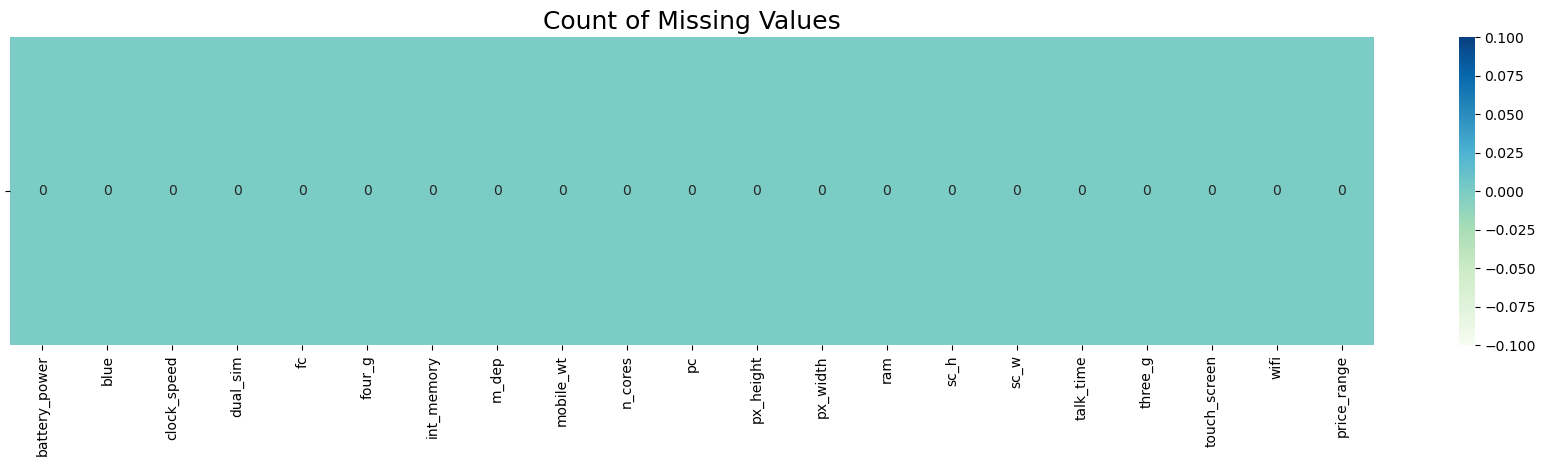

In [10]:
plt.figure(figsize=(22,4))
sns.heatmap((df.isna().sum()).to_frame(name='').T,cmap='GnBu', annot=True,
             fmt='0.0f').set_title('Count of Missing Values', fontsize=18)
plt.show()

In [11]:
unique = df.nunique()
unique.to_frame().T


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,1094,2,26,2,20,2,63,10,121,8,...,1137,1109,1562,15,19,19,2,2,2,4


In [12]:
df_categorical = df[['price_range', 'n_cores', 'blue', 'dual_sim', 'four_g', 'three_g', 'touch_screen', 'wifi']].astype(str)
fig = go.Figure()
for col in set(df.columns) - set(df_categorical):
    fig.add_trace(go.Box(x=df[col], name=col))
fig.show()

In [13]:
unique_counts = df_categorical.nunique()
unique_values = df_categorical.apply(lambda x: x.unique())
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
price_range,4,"[1, 2, 3, 0]"
n_cores,8,"[2, 3, 5, 6, 1, 8, 4, 7]"
blue,2,"[0, 1]"
dual_sim,2,"[0, 1]"
four_g,2,"[0, 1]"
three_g,2,"[0, 1]"
touch_screen,2,"[0, 1]"
wifi,2,"[1, 0]"


In [14]:
df_numerical = df.drop(df_categorical.columns, axis=1)
unique_counts = df_numerical.nunique()
unique_values = df_numerical.apply(lambda x: x.unique())
pd.DataFrame({'Number of Unique Values': unique_counts, 'Unique Values': unique_values})

,Number of Unique Values,Unique Values
battery_power,1094,"[842, 1021, 563, 615, 1821, 1859, 1954, 1445, ..."
clock_speed,26,"[2.2, 0.5, 2.5, 1.2, 1.7, 0.6, 2.9, 2.8, 2.1, ..."
fc,20,"[1, 0, 2, 13, 3, 4, 5, 7, 11, 12, 16, 6, 15, 8..."
int_memory,63,"[7, 53, 41, 10, 44, 22, 24, 9, 33, 17, 52, 46,..."
m_dep,10,"[0.6, 0.7, 0.9, 0.8, 0.1, 0.5, 1.0, 0.3, 0.4, ..."
mobile_wt,121,"[188, 136, 145, 131, 141, 164, 139, 187, 174, ..."
pc,21,"[2, 6, 9, 14, 7, 10, 0, 15, 1, 18, 17, 11, 16,..."
px_height,1137,"[20, 905, 1263, 1216, 1208, 1004, 381, 512, 38..."
px_width,1109,"[756, 1988, 1716, 1786, 1212, 1654, 1018, 1149..."
ram,1562,"[2549, 2631, 2603, 2769, 1411, 1067, 3220, 700..."


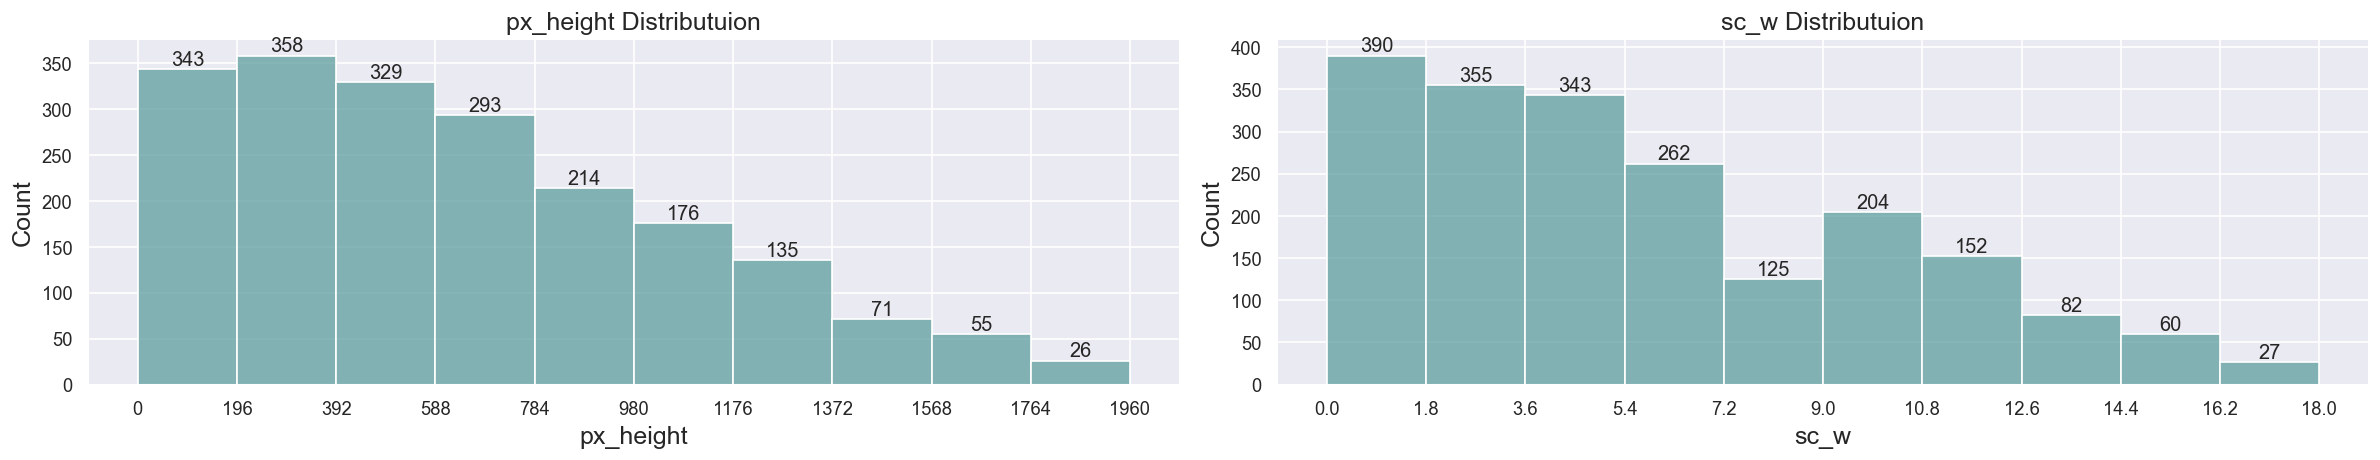

In [15]:
sns.set(rc = {'axes.labelsize' : 15})
fig, ax = plt.subplots(1, 2, figsize=(20,4), dpi=120)
_, bin_edges = np.histogram(df['px_height'], range=(np.floor(df['px_height'].min()), np.ceil(df['px_height'].max())))
g1 = sns.histplot(x='px_height', data=df, bins=bin_edges, color='cadetblue', ax=ax[0])
ax[0].set_xticks(np.round(bin_edges,1))
ax[0].set_title('px_height Distributuion', fontsize=15)
for cont in g1.containers:
        g1.bar_label(cont)
_, bin_edges = np.histogram(df['sc_w'], range=(np.floor(df['sc_w'].min()), np.ceil(df['sc_w'].max())))
g2 = sns.histplot(x='sc_w', data=df, bins=bin_edges, color='cadetblue', ax=ax[1])
ax[1].set_xticks(np.round(bin_edges,1))
ax[1].set_title('sc_w Distributuion', fontsize=15)
for cont in g2.containers:
        g2.bar_label(cont)

plt.tight_layout()
plt.show()

In [16]:
sc_w_Noise = df[df['sc_w'] < 2].index
px_height_Noise = df[df['px_height'] < 5].index
print('detected noise values of sc_w: ', len(sc_w_Noise))
print('detected noise values of px_height: ', len(px_height_Noise))

detected noise values of sc_w:  390
detected noise values of px_height:  9


In [17]:
df.drop(index=[384],inplace=True)

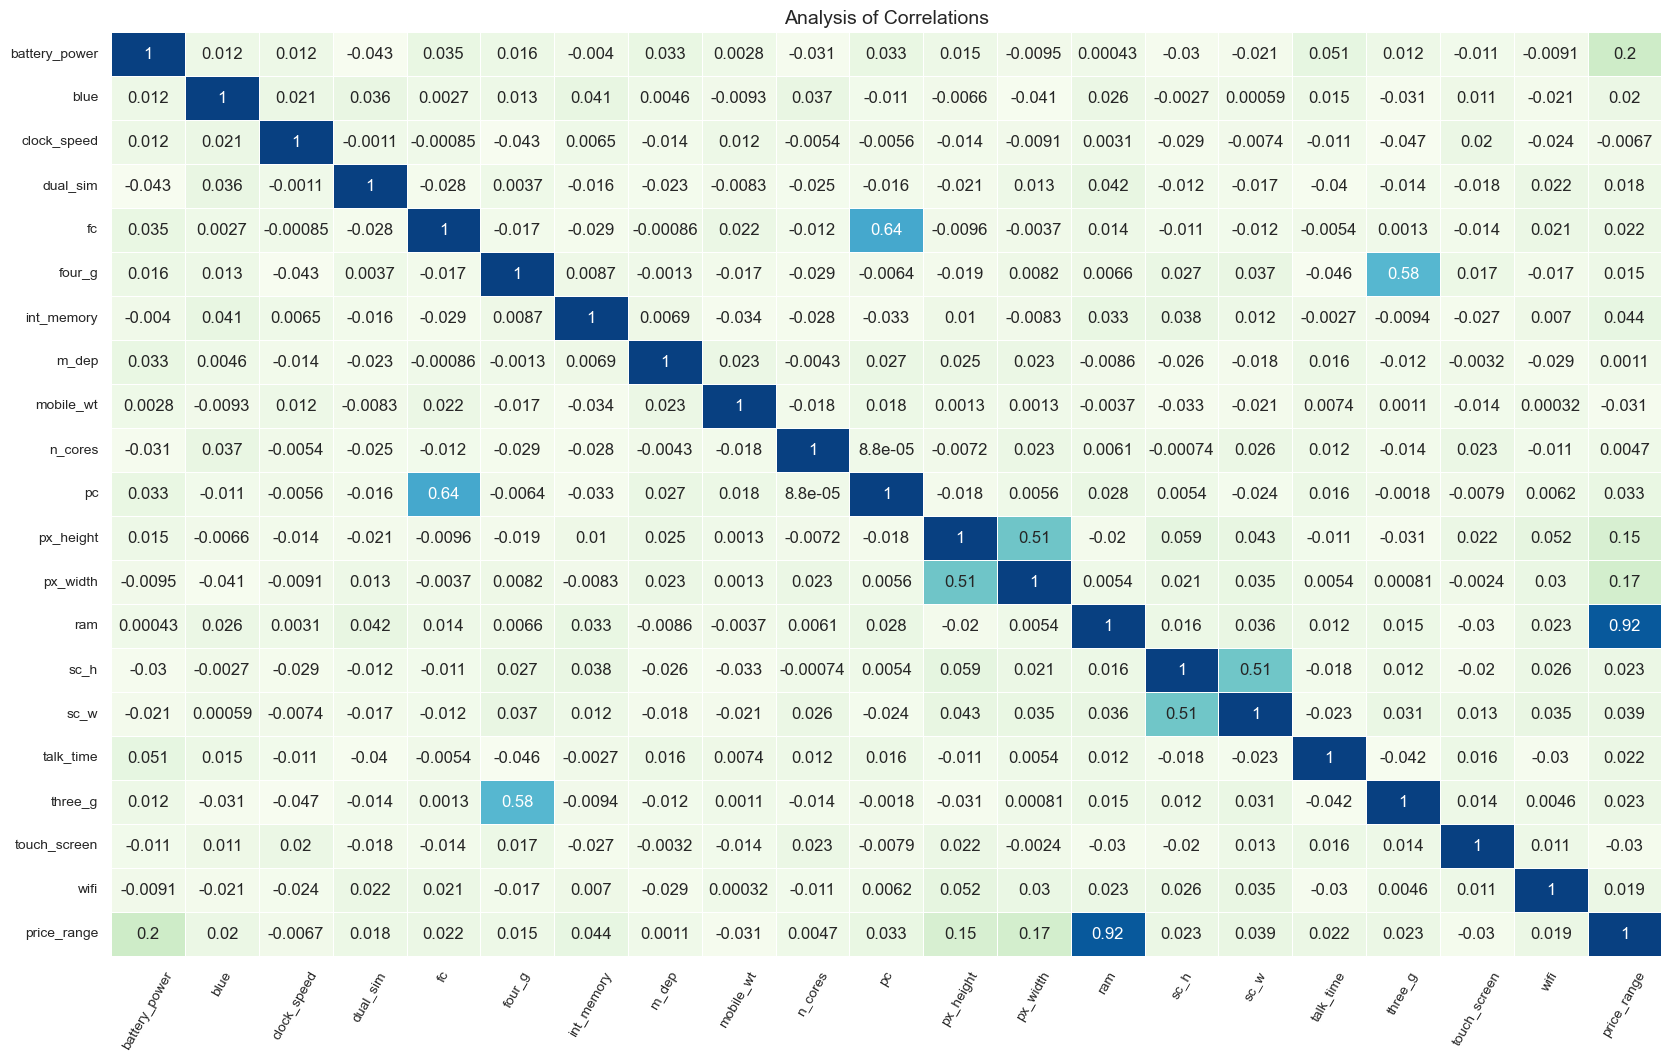

In [18]:
def correlated_map(dataframe, plot=False):
    corr = dataframe.corr()
    if plot:
        sns.set(rc={'figure.figsize': (20, 12)})
        sns.heatmap(corr, cmap="GnBu", annot=True, linewidths=.6 , cbar = False)
        plt.xticks(rotation=60, size=10)
        plt.yticks(size=10)
        plt.title('Analysis of Correlations', size=14)
        plt.show()
correlated_map(df, plot=True)

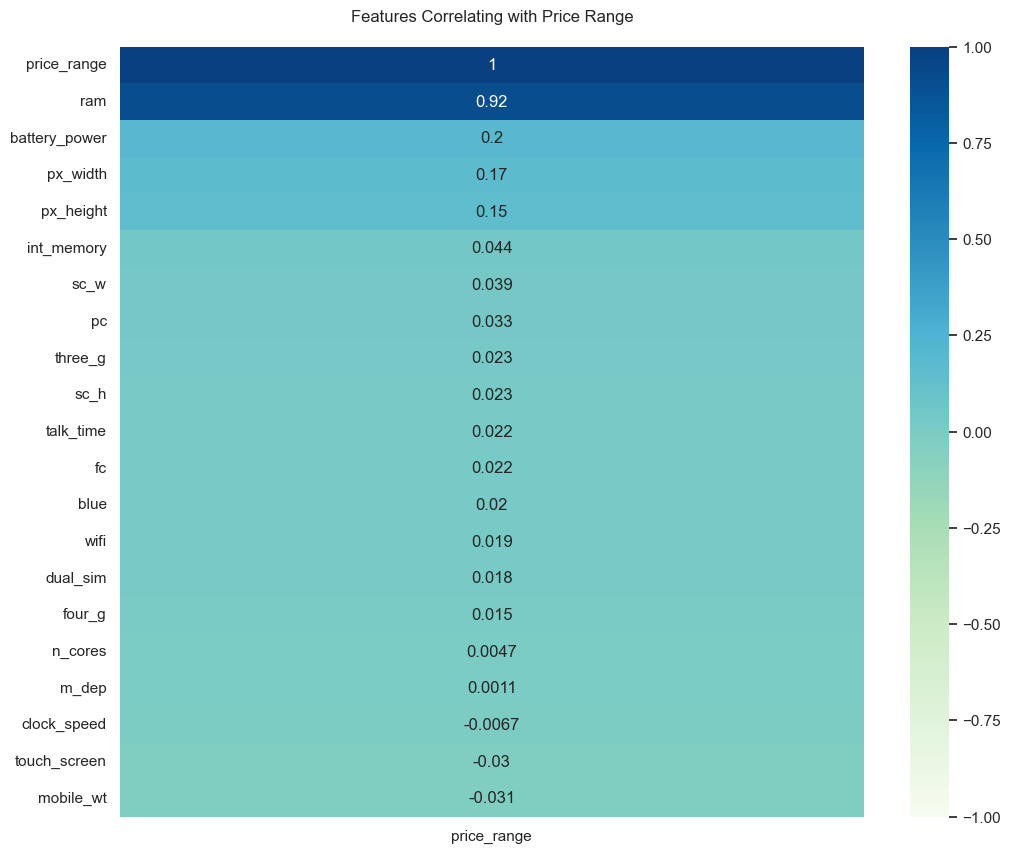

In [19]:
plt.figure (figsize = (12 , 10) , dpi = 100)
heatmap = sns.heatmap (df.corr()[['price_range']].sort_values (by = 'price_range', ascending = False), vmin = -1, vmax = 1, annot = True, cmap = 'GnBu')
heatmap.set_title ('Features Correlating with Price Range', fontdict = {'fontsize':12} , pad = 18);

In [20]:
#ModelsImports
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, KFold, RepeatedStratifiedKFold, GridSearchCV, cross_val_predict
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix, auc, roc_curve, classification_report,
    precision_score, recall_score, f1_score, accuracy_score,
    jaccard_score,
    PrecisionRecallDisplay, RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier



In [21]:
#SVM
X = df.drop('price_range', axis=1)
y = df['price_range'].ravel()
print ('X:', X.shape,'\ny:', y.shape)

X: (1999, 20) 
y: (1999,)


C:\Users\Admin\AppData\Local\Temp\ipykernel_24360\79429898.py:3: FutureWarning:

Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.



In [22]:
# finding the best test size value from 0.2 to 0.3
test_size = np.arange(start=0.2, stop=0.35, step=0.05)
score = []
for size in test_size:
    X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=size, random_state=0)
    svm_model = svm.SVC()
    svm_model.fit (X_train, y_train)
    score.append (svm_model.score (X_test, y_test))
r= pd.DataFrame({'Test size': test_size, 'Score': score})
r.sort_values(by = ['Score'], ascending = False, inplace = True)
r.style.highlight_max(color='#84a98c')

,Test size,Score
0,0.200000,0.957500
2,0.300000,0.950000
1,0.250000,0.948000


In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)
print('number of rows in train data is', X_train.shape)
print('number of rows in test data is', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

number of rows in train data is (1599, 20)
number of rows in test data is (400, 20)
y_train shape: (1599,)
y_test shape: (400,)


In [61]:
scaler = StandardScaler() # scale features
X_train = scaler.fit_transform(X_train) #fit the scaler ro training data
X_test = scaler.transform(X_test)
svm_model = svm.SVC(probability=True)
svm_model.fit(X_train, y_train) #fit model to training data

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [62]:
y_pred = svm_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94       160
           1       0.78      0.82      0.80       143
           2       0.82      0.81      0.82       159
           3       0.94      0.93      0.93       138

    accuracy                           0.87       600
   macro avg       0.87      0.87      0.87       600
weighted avg       0.87      0.87      0.87       600



<Figure size 1200x800 with 0 Axes>

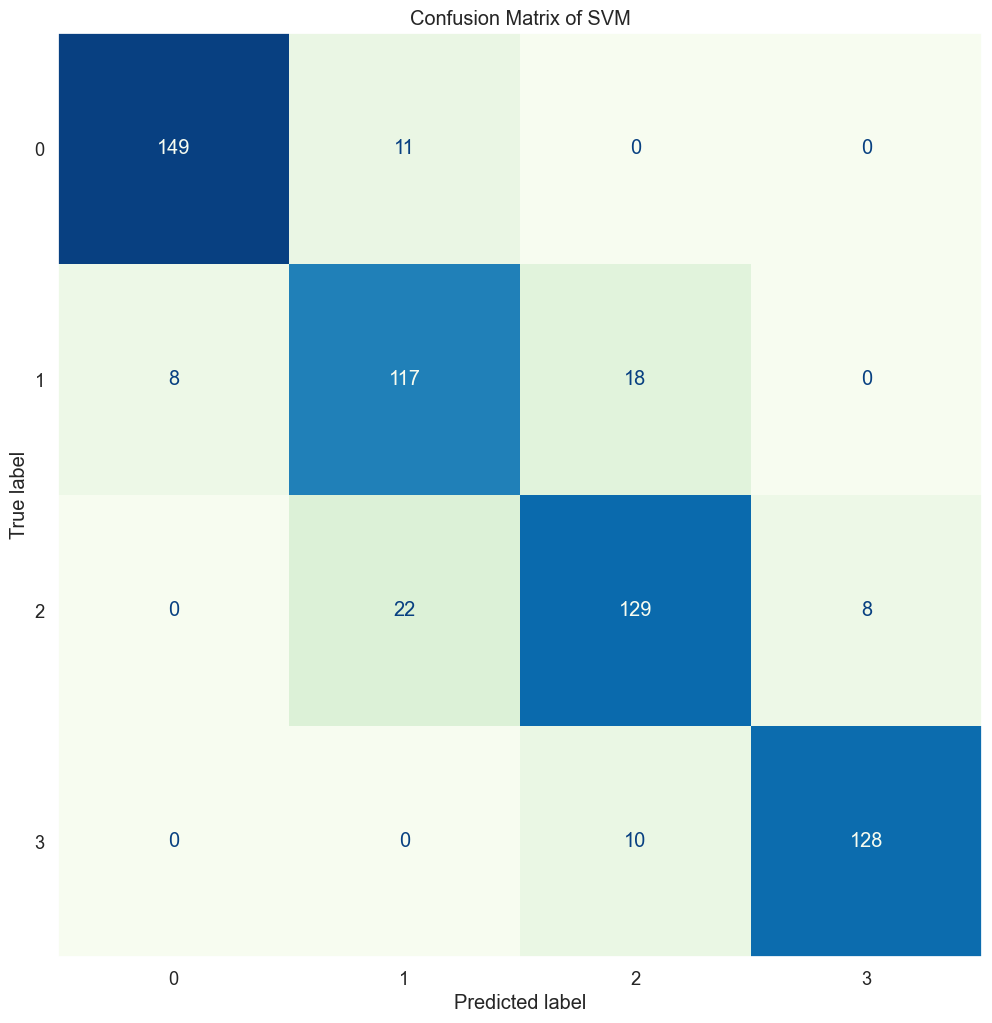

In [63]:
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)
ConfusionMatrixDisplay.from_estimator(svm_model, X_test, y_test, colorbar=False, cmap='GnBu')
plt.title('Confusion Matrix of SVM')
plt.grid(False)

In [64]:
#DesicionTree
X = df.drop('price_range', axis=1)
y = df['price_range'].values.reshape(-1, 1)
print ('X:', X.shape,'\ny:', y.shape)

X: (1999, 20) 
y: (1999, 1)


In [65]:
# finding the best test size value from 0.2 to 0.3
test_size = np.arange(start=0.2, stop=0.35, step=0.05)
score = []
for size in test_size:
    X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=size, random_state=0)
    DT_Clf = DecisionTreeClassifier (max_depth=3)
    DT_Clf.fit (X_train, y_train)
    score.append (DT_Clf.score (X_test, y_test))
r= pd.DataFrame({'Test size': test_size, 'Score': score})
r.sort_values(by = ['Score'], ascending = False, inplace = True)
r.style.highlight_max(color='#84a98c')

,Test size,Score
2,0.300000,0.761667
0,0.200000,0.740000
1,0.250000,0.738000


In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

In [67]:
print('number of rows in train data is', X_train.shape)
print('number of rows in test data is', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

number of rows in train data is (1399, 20)
number of rows in test data is (600, 20)
y_train shape: (1399, 1)
y_test shape: (600, 1)


In [68]:
DT_model = DecisionTreeClassifier(max_depth=3)
DT_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [69]:
y_pred = DT_model.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.93      0.77      0.84       150
           1       0.62      0.87      0.72       150
           2       0.70      0.59      0.64       150
           3       0.88      0.81      0.84       150

    accuracy                           0.76       600
   macro avg       0.78      0.76      0.76       600
weighted avg       0.78      0.76      0.76       600



<Figure size 1200x800 with 0 Axes>

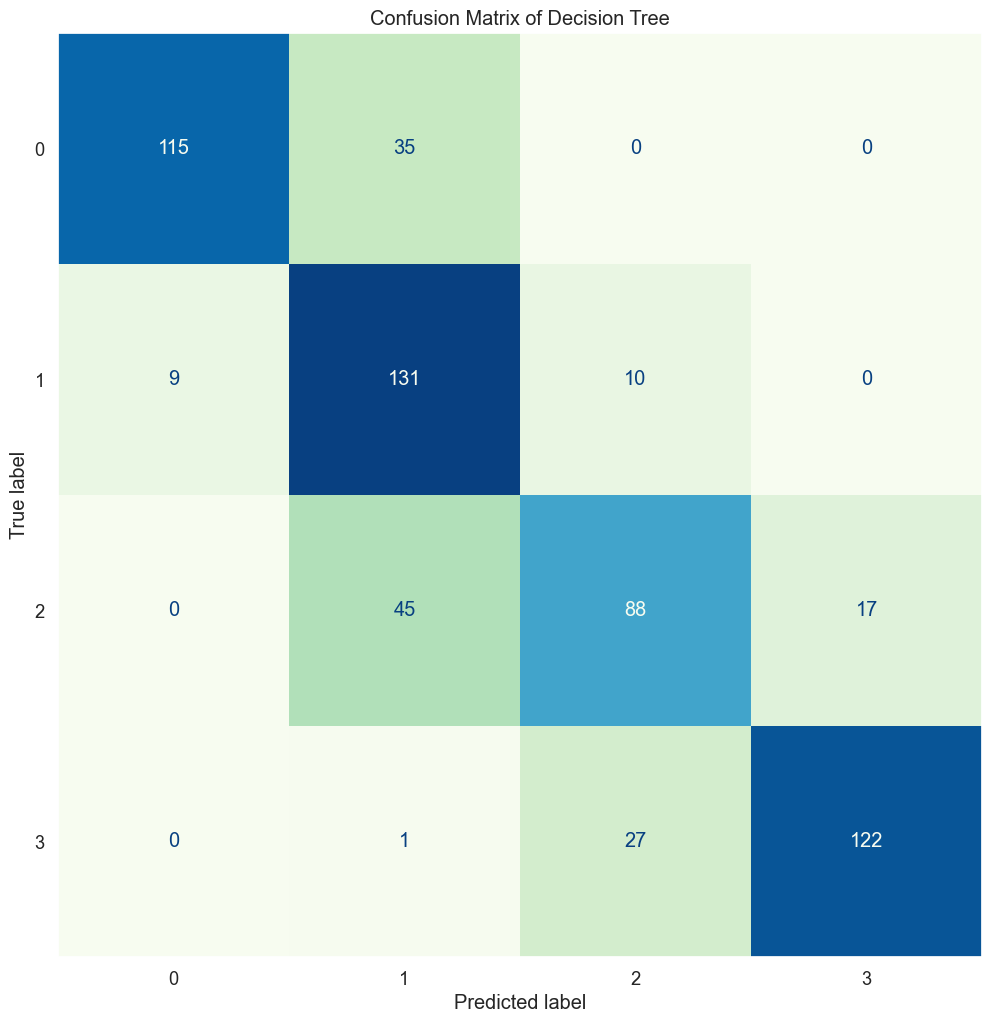

In [70]:
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)
ConfusionMatrixDisplay.from_estimator(DT_model, X_test, y_test, colorbar=False, cmap='GnBu')
plt.title('Confusion Matrix of Decision Tree')
plt.grid(False)

In [71]:
#RandomForest
X = df.drop('price_range', axis=1)
y = df['price_range'].values.ravel()
print ('X:', X.shape,'\ny:', y.shape)

X: (1999, 20) 
y: (1999,)


In [72]:
# finding the best test size value from 0.2 to 0.3
test_size = np.arange(start=0.2, stop=0.35, step=0.05)
score = []
for size in test_size:
    X_train, X_test, y_train, y_test = train_test_split (X, y, test_size=size, random_state=0)
    RF_model = RandomForestClassifier ()
    RF_model.fit (X_train, y_train)
    score.append (RF_model.score (X_test, y_test))
r= pd.DataFrame({'Test size': test_size, 'Score': score})
r.sort_values(by = ['Score'], ascending = False, inplace = True)
r.style.highlight_max(color='#84a98c')

,Test size,Score
2,0.300000,0.873333
0,0.200000,0.865000
1,0.250000,0.864000


In [73]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)

In [74]:
RF_model = RandomForestClassifier()
RF_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [75]:
y_pred = RF_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.91      0.93       125
           1       0.81      0.92      0.86       125
           2       0.90      0.85      0.87       125
           3       0.97      0.93      0.95       125

    accuracy                           0.90       500
   macro avg       0.91      0.90      0.90       500
weighted avg       0.91      0.90      0.90       500



<Figure size 1200x800 with 0 Axes>

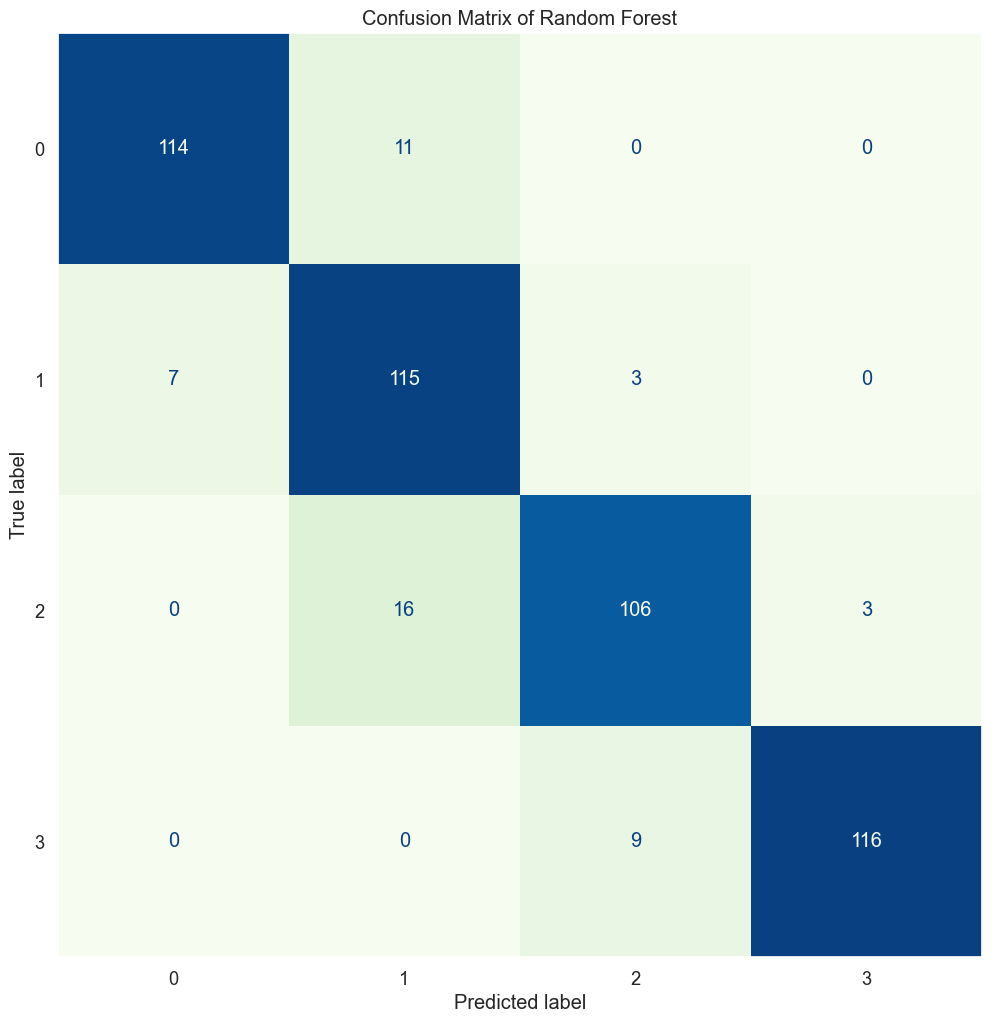

In [76]:
plt.figure(figsize=(12, 8))
sns.set(font_scale=1.2)
ConfusionMatrixDisplay.from_estimator(RF_model, X_test, y_test, colorbar=False, cmap='GnBu')
plt.title('Confusion Matrix of Random Forest')
plt.grid(False)

In [77]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Assuming these are already defined and trained
# svm_model, dt_model, rf_model
# and X_test, y_test

# Predict using all models
svm_pred = svm_model.predict(X_test)
dt_pred = DT_model.predict(X_test)
rf_pred = RF_model.predict(X_test)

# Accuracy comparison
print("Model Accuracy Comparison:")
print(f"SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")

# Classification reports
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_pred))

print("Decision Tree Classification Report:")
print(classification_report(y_test, dt_pred))

print("Random Forest Classification Report:")
print(classification_report(y_test, rf_pred))


Model Accuracy Comparison:
SVM Accuracy: 0.2500
Decision Tree Accuracy: 0.7620
Random Forest Accuracy: 0.9020

SVM Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       125
           1       0.00      0.00      0.00       125
           2       0.25      1.00      0.40       125
           3       0.00      0.00      0.00       125

    accuracy                           0.25       500
   macro avg       0.06      0.25      0.10       500
weighted avg       0.06      0.25      0.10       500

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.75      0.83       125
           1       0.62      0.89      0.73       125
           2       0.71      0.60      0.65       125
           3       0.88      0.81      0.84       125

    accuracy                           0.76       500
   macro avg       0.79      0.76      0.76       500
weighted a

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning:

X has feature names, but SVC was fitted without feature names

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



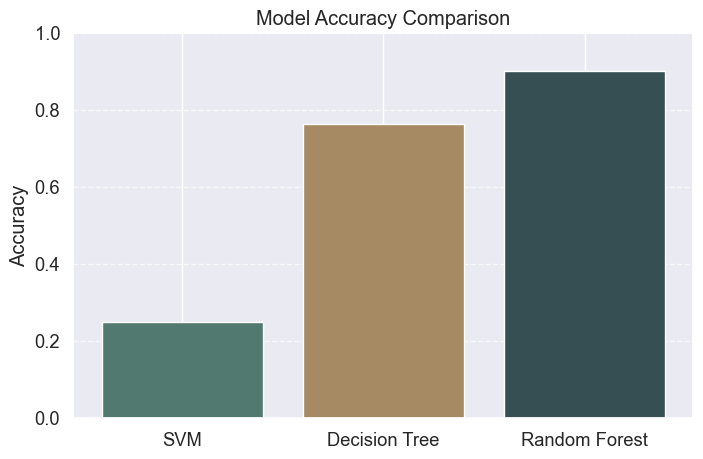

In [80]:

models = ['SVM', 'Decision Tree', 'Random Forest']
accuracies = [
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

# Plot
plt.figure(figsize=(8,5))
plt.bar(models, accuracies, color=['#52796f', '#a68a64', '#354f52'])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.show()


In [81]:
#Predictions
dff = dff.drop('id', axis=1)
dff
cols = dff.columns
# test dataset should also be scaled
scalertest = StandardScaler()
scaledtest = scalertest.fit_transform(dff)
scaled = pd.DataFrame(scaledtest, columns=[cols])
scaled

KeyError: "['id'] not found in axis"

In [82]:
pricerange = RF_model.predict(scaledtest)
predicted = pd.DataFrame({'predicted_price_range': pricerange})
predicted

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



,predicted_price_range
0,0
1,0
2,0
3,0
4,0
...,...
995,0
996,0
997,0
998,0


In [83]:
s = dff.copy()
s['pred'] = pricerange
s.head(20).style.set_properties(**{'background-color': '#84a98c'}, subset=['pred'])

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,pred
0,1043,1,1.800000,1,14,0,5,0.100000,193,3,16,226,1412,3476,12,7,2,0,1,0,0
1,841,1,0.500000,1,4,1,61,0.800000,191,5,12,746,857,3895,6,0,7,1,0,0,0
2,1807,1,2.800000,0,1,0,27,0.900000,186,3,4,1270,1366,2396,17,10,10,0,1,1,0
3,1546,0,0.500000,1,18,1,25,0.500000,96,8,20,295,1752,3893,10,0,7,1,1,0,0
4,1434,0,1.400000,0,11,1,49,0.500000,108,6,18,749,810,1773,15,8,7,1,0,1,0
5,1464,1,2.900000,1,5,1,50,0.800000,198,8,9,569,939,3506,10,7,3,1,1,1,0
6,1718,0,2.400000,0,1,0,47,1.000000,156,2,3,1283,1374,3873,14,2,10,0,0,0,0
7,833,0,2.400000,1,0,0,62,0.800000,111,1,2,1312,1880,1495,7,2,18,0,1,1,0
8,1111,1,2.900000,1,9,1,25,0.600000,101,5,19,556,876,3485,11,9,10,1,1,0,0
9,1520,0,0.500000,0,1,0,25,0.500000,171,3,20,52,1009,651,6,0,5,1,0,1,0


In [84]:
price_range_map = {
    0: 'Low Cost',
    1: 'Medium Cost',
    2: 'High Cost',
    3: 'Very High Cost',}
s['pred_name'] = s['pred'].map(price_range_map)
s.tail(10).style.set_properties(**{'background-color': '#7fc5ba'}, subset=['pred_name'])

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,pred,pred_name
990,1807,0,1.200000,0,4,0,37,0.800000,162,1,11,246,932,2741,7,1,9,1,1,1,0,Low Cost
991,1797,1,2.600000,0,4,0,42,0.600000,174,3,20,57,1169,3359,16,6,18,1,1,1,0,Low Cost
992,1895,0,0.500000,1,0,1,62,0.900000,99,2,0,1019,1698,2563,10,8,13,1,0,1,0,Low Cost
993,567,1,2.700000,1,14,1,56,0.400000,165,8,17,555,1290,336,7,6,7,1,1,1,0,Low Cost
994,936,1,1.400000,1,0,0,46,0.800000,139,2,0,265,886,684,8,5,12,1,1,1,0,Low Cost
995,1700,1,1.900000,0,0,1,54,0.500000,170,7,17,644,913,2121,14,8,15,1,1,0,0,Low Cost
996,609,0,1.800000,1,0,0,13,0.900000,186,4,2,1152,1632,1933,8,1,19,0,1,1,0,Low Cost
997,1185,0,1.400000,0,1,1,8,0.500000,80,1,12,477,825,1223,5,0,14,1,0,0,0,Low Cost
998,1533,1,0.500000,1,0,0,50,0.400000,171,2,12,38,832,2509,15,11,6,0,1,0,0,Low Cost
999,1270,1,0.500000,0,4,1,35,0.100000,140,6,19,457,608,2828,9,2,3,1,0,1,0,Low Cost


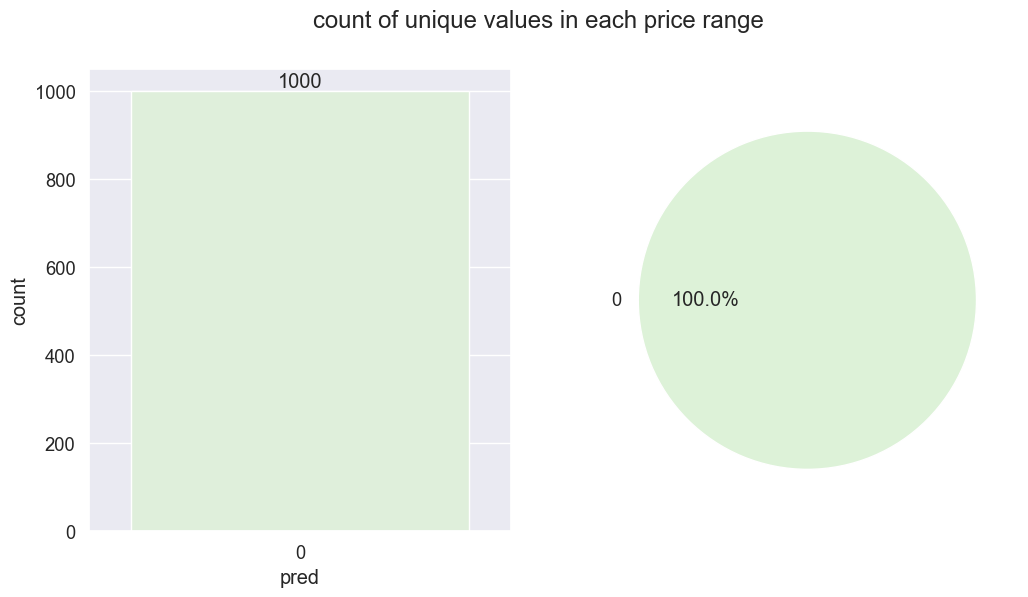

In [85]:
sns.set_palette("GnBu")
fig, axes = plt.subplots(1,2,figsize=(12,6))
sns.countplot(data=s, x='pred', ax=axes[0])
for container in axes[0].containers:
    axes[0].bar_label(container)
slices = s['pred'].value_counts().sort_index().values
activities = [var for var in s['pred'].value_counts().sort_index().index]
axes[1].pie(slices, labels=activities, autopct='%1.1f%%')
plt.suptitle(f'count of unique values in each price range')
plt.show()

In [86]:
# Save the trained models using pickle for use in Streamlit app
import pickle
import os

# Create a models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

# Test models before saving
print("🧪 Testing models before saving...")
sample_data = X_test.iloc[0:1]
sample_scaled = scaler.transform(sample_data)

print(f"SVM prediction: {svm_model.predict(sample_scaled)}")
print(f"DT prediction: {DT_model.predict(sample_scaled)}")
print(f"RF prediction: {RF_model.predict(sample_scaled)}")
print()

# Save the trained models
with open('models/svm_model.pkl', 'wb') as f:
    pickle.dump(svm_model, f)

with open('models/dt_model.pkl', 'wb') as f:
    pickle.dump(DT_model, f)

with open('models/rf_model.pkl', 'wb') as f:
    pickle.dump(RF_model, f)

# Save the scaler used for preprocessing
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature names for reference
with open('models/feature_names.pkl', 'wb') as f:
    pickle.dump(list(X_train.columns), f)

print("✅ Models saved successfully!")
print("📂 Saved models:")
print("   • SVM Model: models/svm_model.pkl")
print("   • Decision Tree Model: models/dt_model.pkl")
print("   • Random Forest Model: models/rf_model.pkl")
print("   • Scaler: models/scaler.pkl")
print("   • Feature Names: models/feature_names.pkl")
print("\n🎯 These models can now be used in the Streamlit app!")

# Test loading and using models
print("\n🔄 Testing loaded models...")
with open('models/rf_model.pkl', 'rb') as f:
    loaded_rf = pickle.load(f)

with open('models/scaler.pkl', 'rb') as f:
    loaded_scaler = pickle.load(f)

test_pred = loaded_rf.predict(loaded_scaler.transform(sample_data))
print(f"Loaded RF prediction: {test_pred}")
print("Models working correctly!" if test_pred[0] == RF_model.predict(sample_scaled)[0] else "❌ Issue detected!")

🧪 Testing models before saving...
SVM prediction: [2]
DT prediction: [0]
RF prediction: [0]

✅ Models saved successfully!
📂 Saved models:
   • SVM Model: models/svm_model.pkl
   • Decision Tree Model: models/dt_model.pkl
   • Random Forest Model: models/rf_model.pkl
   • Scaler: models/scaler.pkl
   • Feature Names: models/feature_names.pkl

🎯 These models can now be used in the Streamlit app!

🔄 Testing loaded models...
Loaded RF prediction: [0]
Models working correctly!


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names

c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but RandomForestClassifier was fitted with feature names



In [87]:
# Fix Random Forest model - train a fresh one
from sklearn.ensemble import RandomForestClassifier

print("🔧 Creating fresh Random Forest model...")

# Create a fresh Random Forest model
RF_model_fresh = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train it on the scaled data
RF_model_fresh.fit(X_train, y_train)

# Test predictions
sample_pred_fresh = RF_model_fresh.predict(X_test.iloc[0:1])
print(f"Fresh RF prediction on test sample: {sample_pred_fresh}")

# Test on various samples
test_samples = X_test.iloc[:5]
fresh_predictions = RF_model_fresh.predict(test_samples)
true_labels = y_test[:5]

print(f"Fresh RF predictions: {fresh_predictions}")
print(f"True labels: {true_labels}")
print(f"Accuracy on these samples: {sum(fresh_predictions == true_labels) / len(true_labels):.2f}")

# Replace the problematic RF_model with the fresh one
RF_model = RF_model_fresh
print("✅ RF_model replaced with fresh model")

🔧 Creating fresh Random Forest model...
Fresh RF prediction on test sample: [2]
Fresh RF predictions: [2 0 3 3 0]
True labels: [2 0 3 3 0]
Accuracy on these samples: 1.00
✅ RF_model replaced with fresh model


📊 FEATURE IMPORTANCE ANALYSIS

🌲 RANDOM FOREST - Top 10 Most Important Features:
-------------------------------------------------------
ram             | 0.4687 | ██████████████████████████████████████████████
battery_power   | 0.0721 | ███████
px_width        | 0.0569 | █████
px_height       | 0.0560 | █████
mobile_wt       | 0.0422 | ████
int_memory      | 0.0391 | ███
talk_time       | 0.0312 | ███
pc              | 0.0306 | ███
clock_speed     | 0.0297 | ██
sc_w            | 0.0293 | ██

🌳 DECISION TREE - Top 10 Most Important Features:
-------------------------------------------------------
ram             | 0.9108 | ███████████████████████████████████████████████████████████████████████████████████████████
battery_power   | 0.0544 | █████
px_height       | 0.0348 | ███
blue            | 0.0000 | 
touch_screen    | 0.0000 | 
three_g         | 0.0000 | 
talk_time       | 0.0000 | 
sc_w            | 0.0000 | 
sc_h            | 0.0000 | 
px_width        | 0.0000 | 


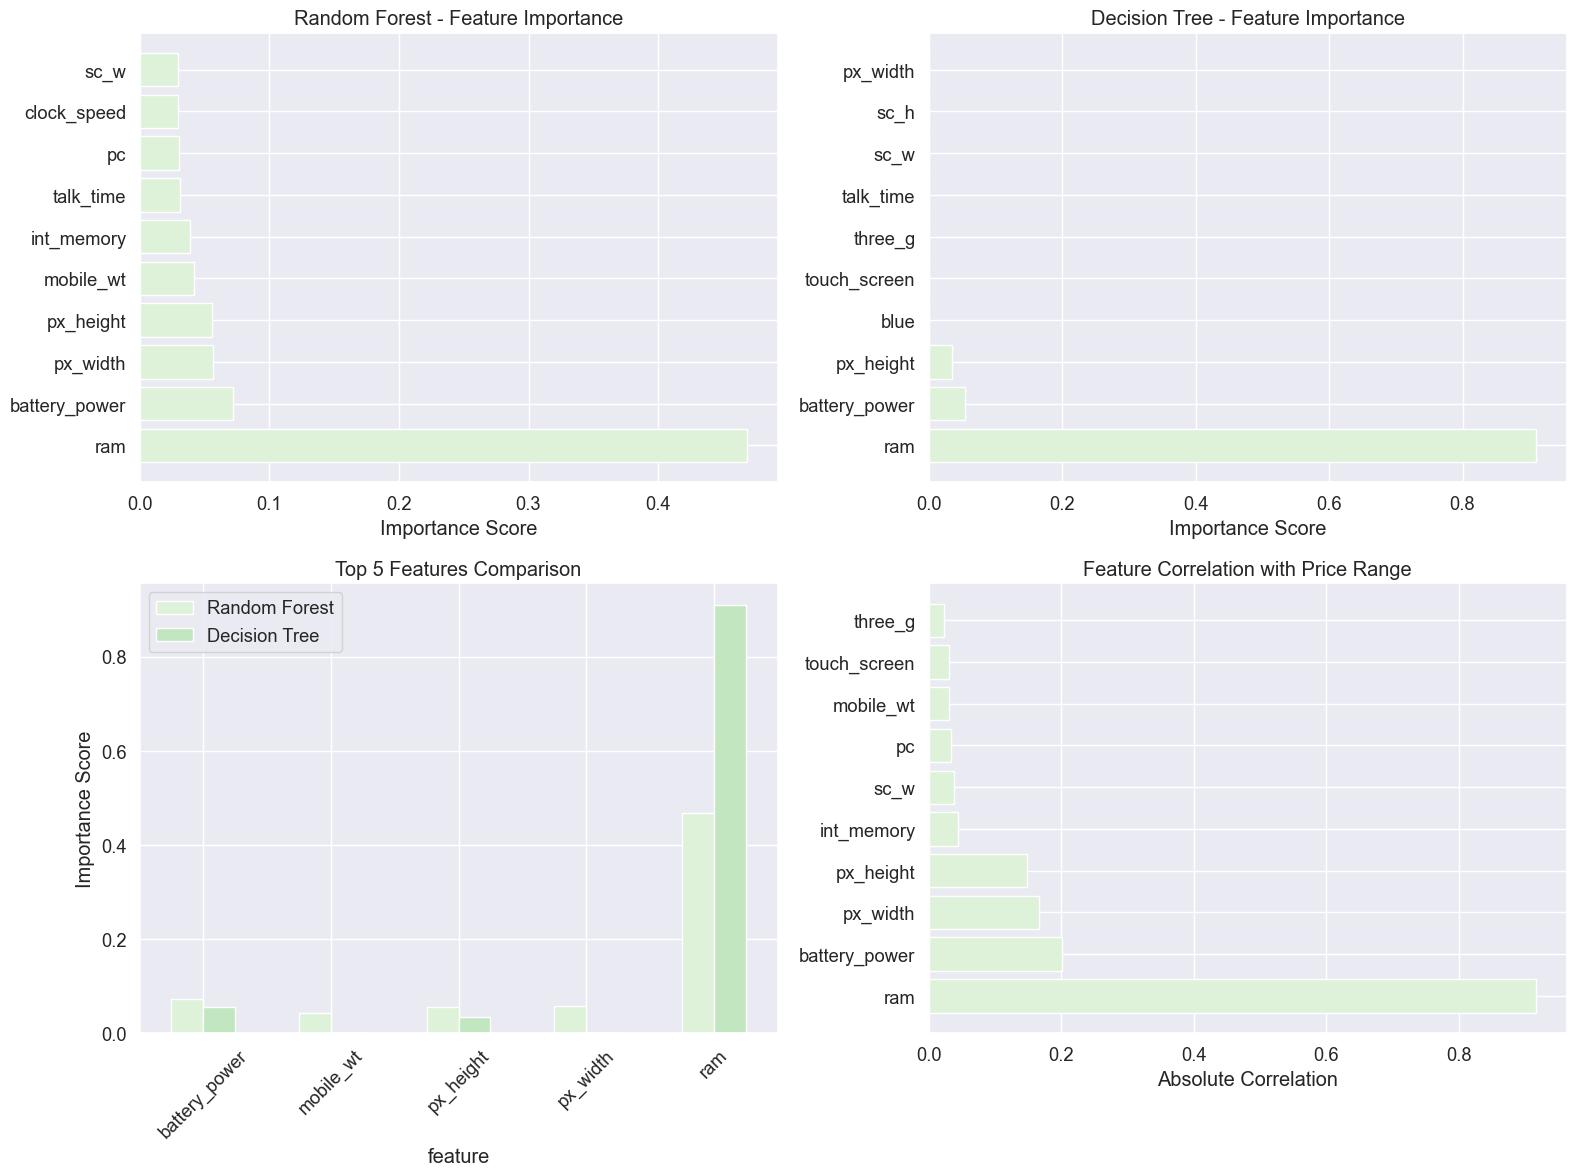


💡 KEY INSIGHTS:
------------------------------
🔥 Most Critical Features (appearing in top 3 across methods):
  • px_width        | Avg Rank: 9.7
  • ram             | Avg Rank: 9.7
  • battery_power   | Avg Rank: 1.3
  • px_height       | Avg Rank: 9.3

📈 Random Forest Top Feature: ram (0.469)
📈 Decision Tree Top Feature: ram (0.911)
📈 Highest Correlation: ram (0.917)

📱 FEATURE CATEGORIES ANALYSIS:
----------------------------------------
Hardware     | Total Importance: 0.701
Display      | Total Importance: 0.178
Camera       | Total Importance: 0.056
Connectivity | Total Importance: 0.065


In [88]:
# Feature Importance Analysis
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 FEATURE IMPORTANCE ANALYSIS")
print("="*50)

# Get feature names
feature_names = X_train.columns.tolist()

# 1. Random Forest Feature Importance
rf_importance = RF_model.feature_importances_
rf_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_importance
}).sort_values('importance', ascending=False)

print("\n🌲 RANDOM FOREST - Top 10 Most Important Features:")
print("-" * 55)
for i, row in rf_feature_importance.head(10).iterrows():
    print(f"{row['feature']:15} | {row['importance']:.4f} | {'█' * int(row['importance'] * 100)}")

# 2. Decision Tree Feature Importance  
dt_importance = DT_model.feature_importances_
dt_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': dt_importance
}).sort_values('importance', ascending=False)

print("\n🌳 DECISION TREE - Top 10 Most Important Features:")
print("-" * 55)
for i, row in dt_feature_importance.head(10).iterrows():
    print(f"{row['feature']:15} | {row['importance']:.4f} | {'█' * int(row['importance'] * 100)}")

# 3. Visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Random Forest importance
axes[0,0].barh(rf_feature_importance['feature'][:10], rf_feature_importance['importance'][:10])
axes[0,0].set_title('Random Forest - Feature Importance')
axes[0,0].set_xlabel('Importance Score')

# Decision Tree importance
axes[0,1].barh(dt_feature_importance['feature'][:10], dt_feature_importance['importance'][:10])
axes[0,1].set_title('Decision Tree - Feature Importance')
axes[0,1].set_xlabel('Importance Score')

# Combined comparison of top 5 features
top_features = rf_feature_importance.head(5)['feature'].tolist()
rf_top5 = rf_feature_importance[rf_feature_importance['feature'].isin(top_features)].set_index('feature')
dt_top5 = dt_feature_importance[dt_feature_importance['feature'].isin(top_features)].set_index('feature')

comparison_df = pd.DataFrame({
    'Random Forest': rf_top5['importance'],
    'Decision Tree': dt_top5['importance']
}).fillna(0)

comparison_df.plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title('Top 5 Features Comparison')
axes[1,0].set_ylabel('Importance Score')
axes[1,0].tick_params(axis='x', rotation=45)

# Feature correlation with price_range
price_correlation = df.corr()['price_range'].abs().sort_values(ascending=False)[1:]  # exclude price_range itself
axes[1,1].barh(price_correlation.head(10).index, price_correlation.head(10).values)
axes[1,1].set_title('Feature Correlation with Price Range')
axes[1,1].set_xlabel('Absolute Correlation')

plt.tight_layout()
plt.show()

# 4. Feature insights
print("\n💡 KEY INSIGHTS:")
print("-" * 30)

# Most important features across models
rf_top3 = rf_feature_importance.head(3)['feature'].tolist()
dt_top3 = dt_feature_importance.head(3)['feature'].tolist()
corr_top3 = price_correlation.head(3).index.tolist()

all_important = set(rf_top3 + dt_top3 + corr_top3)

print("🔥 Most Critical Features (appearing in top 3 across methods):")
for feature in all_important:
    rf_rank = rf_feature_importance[rf_feature_importance['feature'] == feature].index[0] + 1
    dt_rank = dt_feature_importance[dt_feature_importance['feature'] == feature].index[0] + 1
    corr_rank = list(price_correlation.index).index(feature) + 1
    avg_rank = (rf_rank + dt_rank + corr_rank) / 3
    print(f"  • {feature:15} | Avg Rank: {avg_rank:.1f}")

print(f"\n📈 Random Forest Top Feature: {rf_feature_importance.iloc[0]['feature']} ({rf_feature_importance.iloc[0]['importance']:.3f})")
print(f"📈 Decision Tree Top Feature: {dt_feature_importance.iloc[0]['feature']} ({dt_feature_importance.iloc[0]['importance']:.3f})")
print(f"📈 Highest Correlation: {price_correlation.index[0]} ({price_correlation.iloc[0]:.3f})")

# Feature categories
hardware_features = ['battery_power', 'ram', 'int_memory', 'mobile_wt', 'n_cores', 'clock_speed', 'm_dep']
display_features = ['px_height', 'px_width', 'sc_h', 'sc_w', 'touch_screen']
camera_features = ['pc', 'fc']
connectivity_features = ['blue', 'wifi', 'dual_sim', 'three_g', 'four_g', 'talk_time']

print(f"\n📱 FEATURE CATEGORIES ANALYSIS:")
print("-" * 40)

for category, features in [
    ("Hardware", hardware_features),
    ("Display", display_features), 
    ("Camera", camera_features),
    ("Connectivity", connectivity_features)
]:
    category_importance = rf_feature_importance[rf_feature_importance['feature'].isin(features)]['importance'].sum()
    print(f"{category:12} | Total Importance: {category_importance:.3f}")